In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [2]:
data = {
    'job_title_short': ['Data Analyst', 'Data Scientist', 'Data Engineer'],
    'job_skills': [['excel', 'sql', 'python'], ['python', 'r'], ['aws', 'python', 'airflow']]
}

df_skills = pd.DataFrame(data)
df_skills

,job_title_short,job_skills
0,Data Analyst,"[excel, sql, python]"
1,Data Scientist,"[python, r]"
2,Data Engineer,"[aws, python, airflow]"


In [7]:
# Many lines of code to create new columns for each skill and count the total number of jobs that require each skill.
df_skills_list = df_skills.copy()

for row in df_skills.itertuples():
   for skill in row.job_skills:
      df_skills_list[skill]  = df_skills_list['job_skills'].apply(lambda x: skill in x)
      df_skills_list[skill] = df_skills_list[skill].astype(int)

df_skills_list.loc["total"] = df_skills_list.sum(numeric_only=True)

df_skills_list.iloc[:, 1:]

,job_skills,excel,sql,python,r,aws,airflow
0,"[excel, sql, python]",1.0,1.0,1.0,0.0,0.0,0.0
1,"[python, r]",0.0,0.0,1.0,1.0,0.0,0.0
2,"[aws, python, airflow]",0.0,0.0,1.0,0.0,1.0,1.0
total,NaN,1.0,1.0,3.0,1.0,1.0,1.0


In [9]:
# Using explode to transform the job_skills column into multiple rows, where each row corresponds to a single skill. This allows us to easily count the occurrences of each skill across all job titles.
df_exploded = df_skills.explode('job_skills')
df_exploded

,job_title_short,job_skills
0,Data Analyst,excel
0,Data Analyst,sql
0,Data Analyst,python
1,Data Scientist,python
1,Data Scientist,r
2,Data Engineer,aws
2,Data Engineer,python
2,Data Engineer,airflow


In [10]:
df_exploded.value_counts('job_skills')

job_skills
python     3
excel      1
sql        1
r          1
aws        1
airflow    1
Name: count, dtype: int64

<Axes: xlabel='job_skills'>

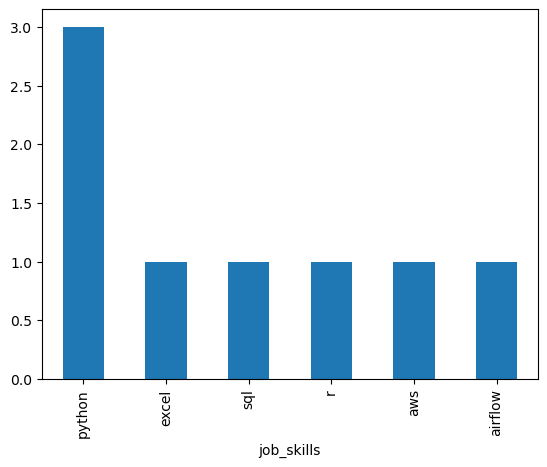

In [11]:
df_exploded['job_skills'].value_counts().plot(kind='bar')

In [12]:
# Convert string representation to actual list, checking for NaN values first
df["job_skills"] = df["job_skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])
df[["job_title_short", "job_skills"]].head(10)

,job_title_short,job_skills
0,Senior Data Engineer,[]
1,Data Analyst,"[r, python, sql, nosql, power bi, tableau]"
2,Data Engineer,"[python, sql, c#, azure, airflow, dax, docker,..."
3,Data Engineer,"[python, c++, java, matlab, aws, tensorflow, k..."
4,Data Engineer,"[bash, python, oracle, aws, ansible, puppet, j..."
5,Data Engineer,"[python, sql, gcp]"
6,Senior Data Engineer,"[sql, python, java, sql server, gcp, bigquery,..."
7,Data Engineer,"[sql, nosql, gcp, azure, aws, bigquery, databr..."
8,Business Analyst,"[excel, powerpoint, power bi]"
9,Data Scientist,"[sql, python, r, mongodb, mongodb, sql server,..."


In [14]:
df_exploded = df.explode('job_skills')
df_exploded["job_skills"]

0                NaN
1                  r
1             python
1                sql
1              nosql
             ...    
785739         kafka
785739    kubernetes
785739        docker
785740           aws
785740          flow
Name: job_skills, Length: 3777320, dtype: str

<Axes: xlabel='job_skills'>

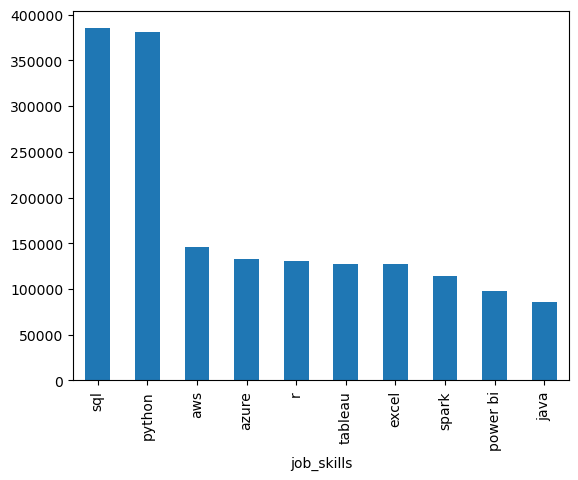

In [17]:
df_exploded['job_skills'].value_counts().head(10).plot(kind='bar')

In [20]:
df_skills = df_skills.explode('job_skills')
df_skills


,job_title_short,job_skills
0,Data Analyst,excel
0,Data Analyst,sql
0,Data Analyst,python
1,Data Scientist,python
1,Data Scientist,r
2,Data Engineer,aws
2,Data Engineer,python
2,Data Engineer,airflow


In [21]:
df_skill_count = df_skills.groupby(['job_skills', "job_title_short"]).size()

print('Type of skills_count: ', type(df_skill_count))
df_skill_count



Type of skills_count:  <class 'pandas.Series'>


job_skills  job_title_short
airflow     Data Engineer      1
aws         Data Engineer      1
excel       Data Analyst       1
python      Data Analyst       1
            Data Engineer      1
            Data Scientist     1
r           Data Scientist     1
sql         Data Analyst       1
dtype: int64

In [22]:
skills_count = df_skill_count.reset_index(name='df_skill_count')
skills_count

,job_skills,job_title_short,df_skill_count
0,airflow,Data Engineer,1
1,aws,Data Engineer,1
2,excel,Data Analyst,1
3,python,Data Analyst,1
4,python,Data Engineer,1
5,python,Data Scientist,1
6,r,Data Scientist,1
7,sql,Data Analyst,1


In [23]:
skills_count.sort_values(by='df_skill_count', inplace=True)

skills_count

,job_skills,job_title_short,df_skill_count
0,airflow,Data Engineer,1
1,aws,Data Engineer,1
2,excel,Data Analyst,1
3,python,Data Analyst,1
4,python,Data Engineer,1
5,python,Data Scientist,1
6,r,Data Scientist,1
7,sql,Data Analyst,1


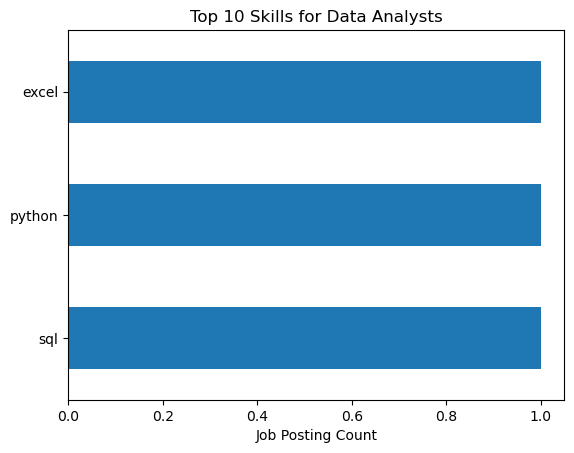

In [27]:
job_title = "Data Analyst"
head_value = 10

df_skills_final = skills_count[skills_count['job_title_short'] == job_title].head(head_value).plot(x='job_skills', y='df_skill_count', kind='barh')
plt.xlabel('Job Posting Count')
plt.ylabel('')
plt.title(f'Top {head_value} Skills for {job_title}s')
plt.gca().invert_yaxis()  # To display the highest value on top
plt.legend().set_visible(False)
plt.show()
